In [5]:
import pandas as pd
import numpy as np
import nfl_data_py as nfl
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [6]:
# seasons = range(2006, 2024)     #Passing stats started in 2006
pbp_py = nfl.import_pbp_data([2022, 2023, 2024])
# pbp_py_2016 = nfl.import_pbp_data([2016])

2022 done.
2023 done.
2024 done.
Downcasting floats.


In [7]:
pbp_py[:10].to_csv('small_data.csv')

From defensive perspective, predicting what the offense is going to run based on situational context (time reamining, downs, distance) and offensive formation

In [8]:
game_situation = ["yardline_100", "quarter_seconds_remaining", "half_seconds_remaining", "game_seconds_remaining", "drive", "qtr", "down", "ydstogo", "score_differential", "xpass"] 
offensive = ["offense_formation", "offense_personnel"]
defensive = ["defenders_in_box", "defense_personnel", "number_of_pass_rushers", "defense_man_zone_type", "defense_coverage_type"]
play_type = ["play_type", "run_location", "run_gap", "pass_location", "pass_length"]

df = pbp_py[game_situation + offensive + defensive + play_type]
df[:5]

,yardline_100,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,drive,qtr,down,ydstogo,score_differential,xpass,...,defenders_in_box,defense_personnel,number_of_pass_rushers,defense_man_zone_type,defense_coverage_type,play_type,run_location,run_gap,pass_location,pass_length
0,NaN,900.0,1800.0,3600.0,NaN,1.0,NaN,0.0,NaN,NaN,...,NaN,None,NaN,None,None,None,None,None,None,None
1,35.0,900.0,1800.0,3600.0,1.0,1.0,NaN,0.0,0.0,NaN,...,NaN,None,NaN,None,None,kickoff,None,None,None,None
2,78.0,896.0,1796.0,3596.0,1.0,1.0,1.0,10.0,0.0,0.440373,...,7.0,"3 DL, 4 LB, 4 DB",NaN,None,None,run,left,end,None,None
3,59.0,869.0,1769.0,3569.0,1.0,1.0,1.0,10.0,0.0,0.389904,...,6.0,"3 DL, 4 LB, 4 DB",4.0,ZONE_COVERAGE,COVER_2,pass,None,None,left,short
4,59.0,865.0,1765.0,3565.0,1.0,1.0,2.0,10.0,0.0,0.443575,...,7.0,"3 DL, 4 LB, 4 DB",NaN,None,None,run,left,end,None,None


In [9]:
df = df.dropna(subset=["yardline_100", "play_type"]).reset_index(drop=True)
df = df.loc[df['play_type'].isin(['run', 'pass'])]
df[:5]
len(df)

106080

In [10]:
df_combined = df.copy()

def combine_columns(row):
    if row['play_type'] == 'run':
        return f"{row['play_type']}_{row['run_location']}_{row['run_gap']}"
    elif row['play_type'] == 'pass':
        return f"{row['play_type']}_{row['pass_location']}_{row['pass_length']}"
    else:
        return None  # or any default value

df_combined['combined'] = df_combined.apply(combine_columns, axis=1)


In [11]:
# df_combined = df_combined.drop(["play_type", "run_location", "run_gap", "pass_location", "pass")
df_combined = df_combined[~df_combined['combined'].isin(['run_right_None', 'pass_None_None', 'run_None_None'])]

In [12]:
df_combined.groupby("combined").count()

# Replace NaN with 0
df_combined = df_combined.fillna(0)
df_combined.head(10)

,yardline_100,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,drive,qtr,down,ydstogo,score_differential,xpass,...,defense_personnel,number_of_pass_rushers,defense_man_zone_type,defense_coverage_type,play_type,run_location,run_gap,pass_location,pass_length,combined
1,78.0,896.0,1796.0,3596.0,1.0,1.0,1.0,10.0,0.0,0.440373,...,"3 DL, 4 LB, 4 DB",0.0,0,0,run,left,end,0,0,run_left_end
2,59.0,869.0,1769.0,3569.0,1.0,1.0,1.0,10.0,0.0,0.389904,...,"3 DL, 4 LB, 4 DB",4.0,ZONE_COVERAGE,COVER_2,pass,0,0,left,short,pass_left_short
3,59.0,865.0,1765.0,3565.0,1.0,1.0,2.0,10.0,0.0,0.443575,...,"3 DL, 4 LB, 4 DB",0.0,0,0,run,left,end,0,0,run_left_end
4,54.0,841.0,1741.0,3541.0,1.0,1.0,3.0,5.0,0.0,0.963242,...,"3 DL, 4 LB, 4 DB",4.0,ZONE_COVERAGE,COVER_3,pass,0,0,right,short,pass_right_short
6,72.0,822.0,1722.0,3522.0,2.0,1.0,1.0,10.0,0.0,0.479318,...,"4 DL, 3 LB, 4 DB",4.0,ZONE_COVERAGE,COVER_3,pass,0,0,right,short,pass_right_short
7,68.0,801.0,1701.0,3501.0,2.0,1.0,2.0,6.0,0.0,0.608057,...,"4 DL, 3 LB, 4 DB",3.0,ZONE_COVERAGE,COVER_4,pass,0,0,left,short,pass_left_short
8,64.0,761.0,1661.0,3461.0,2.0,1.0,3.0,2.0,0.0,0.798116,...,"4 DL, 3 LB, 4 DB",0.0,0,0,run,right,tackle,0,0,run_right_tackle
9,60.0,721.0,1621.0,3421.0,2.0,1.0,1.0,10.0,0.0,0.494007,...,"4 DL, 3 LB, 4 DB",0.0,0,0,run,right,end,0,0,run_right_end
10,60.0,679.0,1579.0,3379.0,2.0,1.0,2.0,10.0,0.0,0.565180,...,"3 DL, 3 LB, 5 DB",4.0,ZONE_COVERAGE,COVER_3,pass,0,0,left,short,pass_left_short
11,52.0,640.0,1540.0,3340.0,2.0,1.0,3.0,2.0,0.0,0.743528,...,"3 DL, 4 LB, 4 DB",0.0,0,0,run,right,tackle,0,0,run_right_tackle


In [13]:
X = pd.get_dummies(df_combined[game_situation + offensive + defensive])
y = df_combined["combined"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                   precision    recall  f1-score   support

   pass_left_deep       0.08      0.02      0.03       810
  pass_left_short       0.27      0.36      0.31      3456
 pass_middle_deep       0.05      0.01      0.01       396
pass_middle_short       0.16      0.08      0.11      1996
  pass_right_deep       0.10      0.02      0.04       836
 pass_right_short       0.30      0.46      0.36      3832
     run_left_end       0.14      0.11      0.13      1232
   run_left_guard       0.10      0.07      0.08      1099
  run_left_tackle       0.13      0.09      0.10      1057
  run_middle_None       0.27      0.46      0.34      2275
    run_right_end       0.17      0.11      0.13      1150
  run_right_guard       0.13      0.08      0.10      1101
 run_right_tackle       0.12      0.07      0.09       983

         accuracy                           0.24     20223
        macro avg       0.16      0.15      0.14     20223
     weighted avg       0.20      0.24      0.21     2

<h2>GridSearchCV</h2>

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None]
}

clf = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,                     # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,                # Use all CPU cores
    verbose=1
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Score: 0.2674619854122883
Test Accuracy: 0.2766157345596598


In [ ]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Create tensors
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
BATCH_SIZE    = 512
EPOCHS        = 25
LEARNING_RATE = 3e-4

X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long, device=DEVICE)
y_test_t  = torch.tensor(y_test_enc,  dtype=torch.long, device=DEVICE)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Define neural network model
class PlayClassifier(nn.Module):
    def __init__(self, in_features: int, n_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

model = PlayClassifier(in_features=X_train.shape[1], n_classes=len(le.classes_)).to(DEVICE)

# Define loss function, optimizer, and learning rate scheduler
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2, verbose=True)

# Train the model
def run_epoch(loader, train: bool):
    model.train(mode=train)
    total, correct, running_loss = 0, 0, 0.0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            logits = model(xb)
            loss   = criterion(logits, yb)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds        = logits.argmax(1)
            correct     += (preds == yb).sum().item()
            total       += xb.size(0)

    acc  = correct / total
    loss = running_loss / total
    return loss, acc

history = {"train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(test_loader,  train=False)
    scheduler.step(val_acc)

    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch:02}/{EPOCHS} "
          f"| train acc: {tr_acc:6.3%} "
          f"| val acc: {val_acc:6.3%} "
          f"| val loss: {val_loss:8.4f}")

e:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01/25 | train acc: 16.255% | val acc: 18.434% | val loss:   2.3755
Epoch 02/25 | train acc: 18.499% | val acc: 19.260% | val loss:   2.3522
Epoch 03/25 | train acc: 21.041% | val acc: 23.691% | val loss:   2.1640
Epoch 04/25 | train acc: 24.548% | val acc: 25.797% | val loss:   2.0063
Epoch 05/25 | train acc: 25.144% | val acc: 25.881% | val loss:   2.0351
Epoch 06/25 | train acc: 25.396% | val acc: 26.129% | val loss:   1.9542
Epoch 07/25 | train acc: 25.720% | val acc: 26.549% | val loss:   1.9305
Epoch 08/25 | train acc: 25.876% | val acc: 25.817% | val loss:   1.9513
Epoch 09/25 | train acc: 26.018% | val acc: 26.455% | val loss:   1.9385
Epoch 10/25 | train acc: 26.116% | val acc: 25.619% | val loss:   1.9503
Epoch 11/25 | train acc: 26.147% | val acc: 26.470% | val loss:   1.9229
Epoch 12/25 | train acc: 26.186% | val acc: 26.524% | val loss:   1.9197
Epoch 13/25 | train acc: 26.179% | val acc: 26.460% | val loss:   1.9168
Epoch 14/25 | train acc: 26.307% | val acc: 26.747%

In [ ]:
import torch, pandas as pd, numpy as np
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from itertools import product
from collections import defaultdict

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

def make_loaders(batch_size=512, test_frac=0.2):
    X_train, X_test, y_tr, y_te = train_test_split(
        X, y_enc, test_size=test_frac, random_state=42, stratify=y_enc
    )
    X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test.values,  dtype=torch.float32)
    y_train_t = torch.tensor(y_tr, dtype=torch.long)
    y_test_t  = torch.tensor(y_te, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                              batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                              batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, X_train.shape[1]

# Define the neural network model
class PlayClassifier(nn.Module):
    def __init__(self, in_features, n_classes, dropout=0.25, h1=256, h2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(h2, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

# Train the model
def train_once(params):
    """
    params: dict with keys
        lr, batch_size, dropout, epochs
    Returns (history_df, best_val_acc)
    """
    epochs     = params["epochs"]
    lr         = params["lr"]
    dropout    = params["dropout"]
    batch_size = params["batch_size"]

    tl, vl, in_feats = make_loaders(batch_size=batch_size)
    model = PlayClassifier(in_features=in_feats,
                           n_classes=len(le.classes_),
                           dropout=dropout).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched     = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                           mode="max", factor=0.5,
                                                           patience=2, verbose=False)

    def run_epoch(loader, train):
        model.train(train)
        total, correct, loss_sum = 0, 0, 0.
        with (torch.enable_grad() if train else torch.no_grad()):
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss   = criterion(logits, yb)
                if train:
                    optimizer.zero_grad(); loss.backward(); optimizer.step()
                loss_sum += loss.item() * xb.size(0)
                correct  += (logits.argmax(1) == yb).sum().item()
                total    += xb.size(0)
        return loss_sum/total, correct/total

    hist = defaultdict(list)
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = run_epoch(tl, True)
        vl_loss, vl_acc = run_epoch(vl, False)
        sched.step(vl_acc)

        hist["epoch"].append(ep)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(vl_acc)

    hist_df = pd.DataFrame(hist)
    return hist_df, hist_df["val_acc"].max()


Device: cuda


▶ running {'lr': 0.0003, 'batch_size': 256, 'dropout': 0.25, 'epochs': 20}


e:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   best val acc: 26.737%
▶ running {'lr': 0.0003, 'batch_size': 256, 'dropout': 0.4, 'epochs': 20}


e:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   best val acc: 26.717%
▶ running {'lr': 0.0003, 'batch_size': 512, 'dropout': 0.25, 'epochs': 20}


...

   best val acc: 26.767%
▶ running {'lr': 0.001, 'batch_size': 512, 'dropout': 0.25, 'epochs': 20}


e:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   best val acc: 26.727%
▶ running {'lr': 0.001, 'batch_size': 512, 'dropout': 0.4, 'epochs': 20}


e:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   best val acc: 26.712%


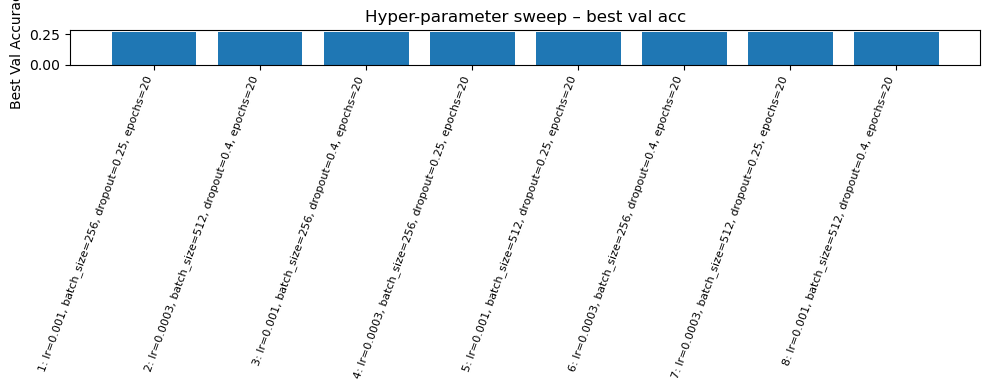

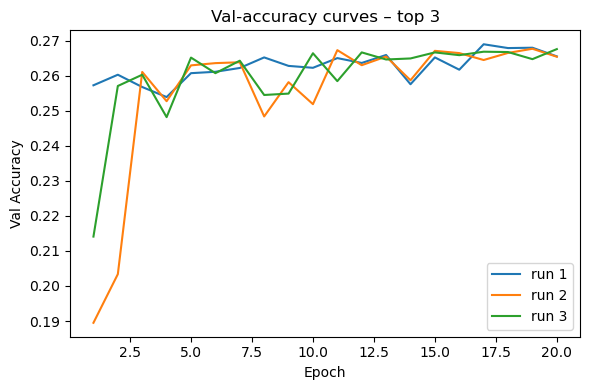

🏆 best params → {'lr': 0.001, 'batch_size': 256, 'dropout': 0.25, 'epochs': 20}


In [19]:
grid = {
    "lr":         [3e-4, 1e-3],
    "batch_size": [256, 512],
    "dropout":    [0.25, 0.4],
    "epochs":     [20],
}

experiments = list(product(*grid.values()))
key_names   = list(grid.keys())

# each item: (params_dict, hist_df, best_acc)
results = []

# Iterate over combinations of hyper-parameters
for combo in experiments:
    params = dict(zip(key_names, combo))
    print("▶ running", params)
    hist_df, best = train_once(params)
    results.append((params, hist_df, best))
    print(f"   best val acc: {best:.3%}")

# Sort by best accuracy descending
results.sort(key=lambda tup: tup[2], reverse=True)

# Create plots
# (a) bar of best val acc for each run
labels = [f"{i}: " + ", ".join(f"{k}={v}" for k, v in r[0].items())
          for i, r in enumerate(results, 1)]
best_accs = [r[2] for r in results]

plt.figure(figsize=(10, 4))
plt.bar(range(len(best_accs)), best_accs)
plt.xticks(range(len(best_accs)), labels, rotation=70, ha='right', fontsize=8)
plt.ylabel("Best Val Accuracy")
plt.title("Hyper-parameter sweep – best val acc")
plt.tight_layout()
plt.show()

# (b) training curves for the top-3 configs
top_N = 3
plt.figure(figsize=(6, 4))
for i, (_, hist_df, _) in enumerate(results[:top_N], 1):
    plt.plot(hist_df["epoch"], hist_df["val_acc"], label=f"run {i}")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy")
plt.title(f"Val-accuracy curves – top {top_N}")
plt.legend()
plt.tight_layout()
plt.show()

best_params = results[0][0]
print("best params: ", best_params)